# Nuclear Waste Canister Temperature Prediction — Neural Network
**CIVIL-226 - Introduction to Machine Learning for Engineers — EPFL**  
**Team name:** [To fill]  
**Members:** [To fill]

## Objective
Predict the temperature around nuclear waste canisters at unobserved sensor positions,
using heating power, time, spatial coordinates, and cumulative energy.

This notebook implements a deep neural network trained with AdamW optimizer and Huber loss,
with a sensor-based train/validation split to better estimate generalization performance.

In [1]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"]="TRUE"
import torch
import torchvision
import pandas as pd
import numpy as np
import torch.nn as nn

device = "cuda" if torch.cuda.is_available() else "cpu"
print(f'Device: {device}')
if device == "cuda":
    print(f'GPU: {torch.cuda.get_device_name(0)}')
    print(f'VRAM: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB')
else:
    print('No GPU found — running on CPU')
    print('To enable GPU: pip install torch --index-url https://download.pytorch.org/whl/cu118')


Device: cuda
GPU: NVIDIA GeForce RTX 3070 Ti Laptop GPU
VRAM: 8.6 GB


In [2]:
train = pd.read_parquet("train.parquet")
test = pd.read_parquet("test.parquet")
sensors = pd.read_parquet("sensors.parquet")

## Merge sensor positions into train data

In [3]:
train_full = train.merge(sensors, on="sensor", how="left")
print(train_full.head())
print(train_full.shape)

  sensor       time        power  temperature     coor_x  coor_y  coor_z
0   N102        0.0  1487.964722    17.514429  46.131474     3.5     0.0
1   N102   864000.0  1487.288818    17.820795  46.131474     3.5     0.0
2   N102  1728000.0  1486.612915    17.573187  46.131474     3.5     0.0
3   N102  2592000.0  1485.936890    16.513235  46.131474     3.5     0.0
4   N102  3456000.0  1485.260986    16.303427  46.131474     3.5     0.0
(6626928, 7)


## Clean missing values

In [4]:
train_full = train_full.dropna()
print(train_full.shape)
print(train_full.columns)

(6527525, 7)
Index(['sensor', 'time', 'power', 'temperature', 'coor_x', 'coor_y', 'coor_z'], dtype='str')


## Data exploration

Temperature min: -292.15085
Temperature max: 6039.05

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


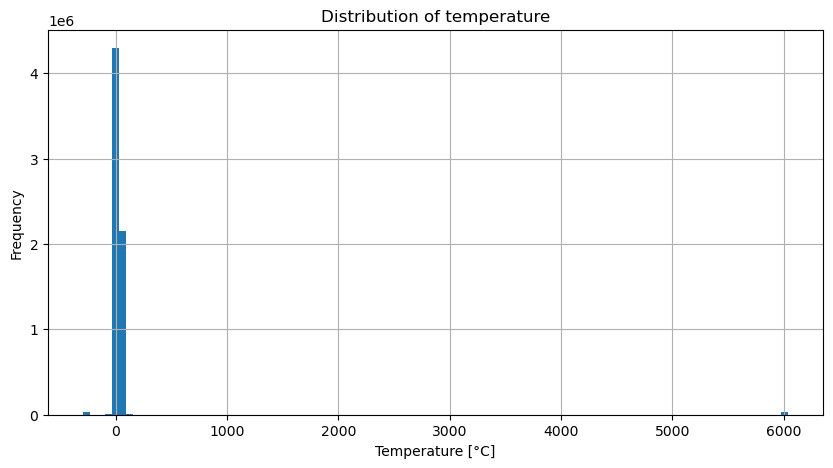

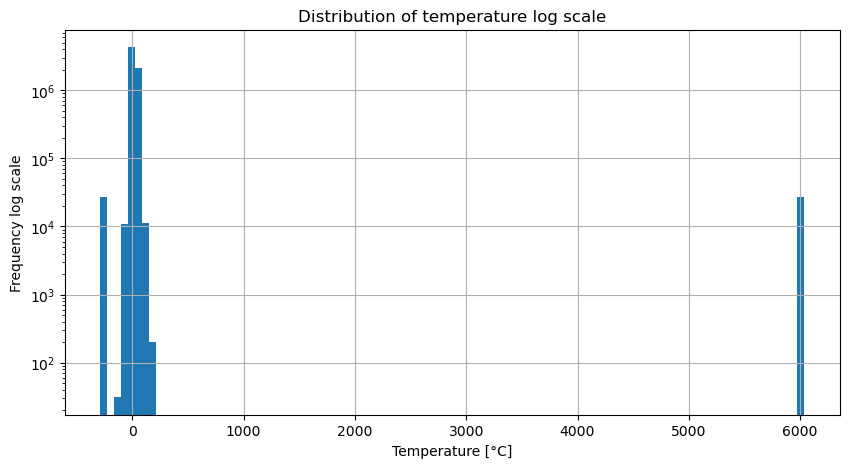

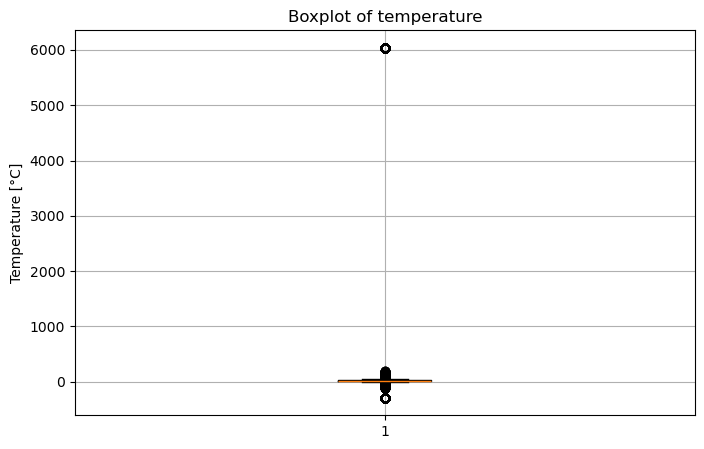

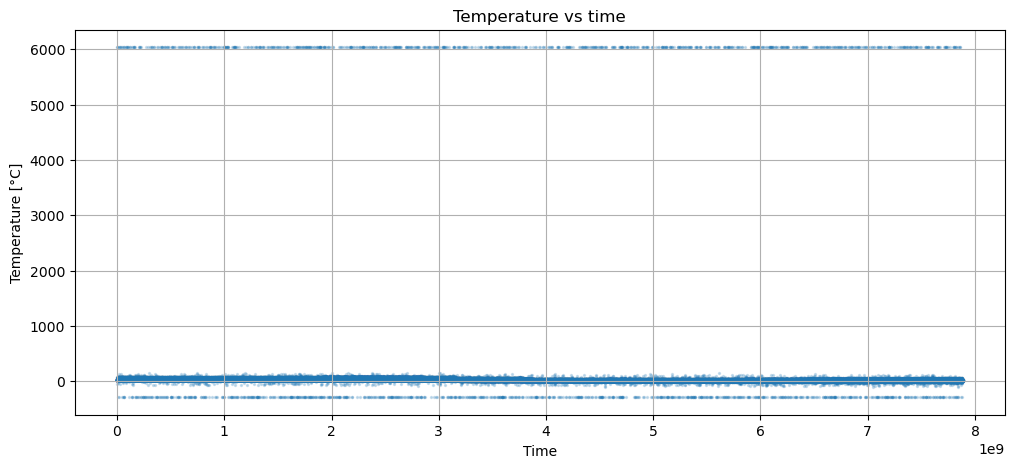

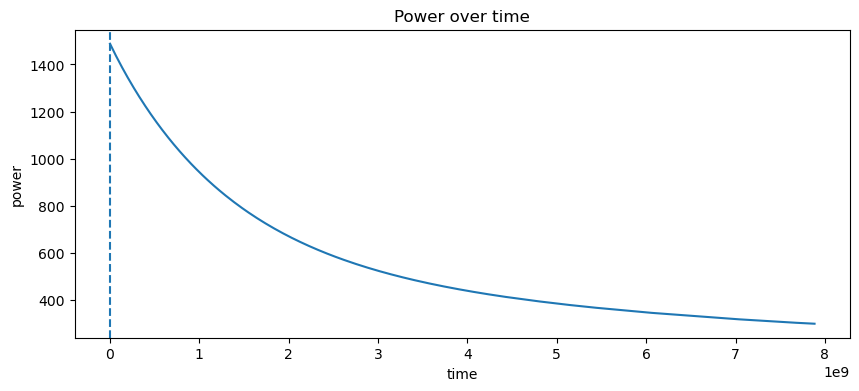

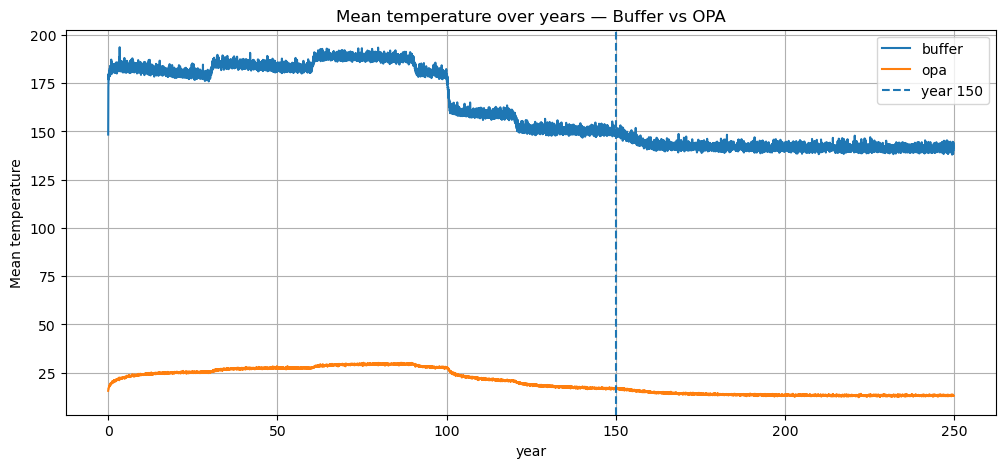

In [5]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

# Histogram (frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()

# Histogram (log frequency_temperature)
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()

# Box plot
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()

# Temperature_Time
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

# Power_time
power_time = (
    train_full[["time", "power"]]
    .drop_duplicates("time")
    .sort_values("time")
)

plt.figure(figsize=(10, 4))
plt.plot(power_time["time"], power_time["power"])
plt.axvline(150, linestyle="--")
plt.xlabel("time")
plt.ylabel("power")
plt.title("Power over time")
plt.show()


# ============================================================
# Mean temperature over years — BUFFER vs OPA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

THRESHOLD_X = 1.4
SECONDS_PER_YEAR = 365.25 * 24 * 3600

df = train_full.copy()

df["year"] = df["time"] / SECONDS_PER_YEAR

df["zone"] = np.where(
    df["coor_x"] < THRESHOLD_X,
    "buffer",
    "opa"
)

temp_mean_by_year = (
    df
    .groupby(["year", "zone"], as_index=False)["temperature"]
    .mean()
    .rename(columns={"temperature": "mean_temperature"})
)

plt.figure(figsize=(12, 5))

for zone_name in ["buffer", "opa"]:
    df_zone = temp_mean_by_year[temp_mean_by_year["zone"] == zone_name]
    plt.plot(
        df_zone["year"],
        df_zone["mean_temperature"],
        label=zone_name
    )

plt.axvline(150, linestyle="--", label="year 150")

plt.xlabel("year")
plt.ylabel("Mean temperature")
plt.title("Mean temperature over years — Buffer vs OPA")
plt.legend()
plt.grid(True)
plt.show()

## Remove outliers and sensor drift

Diagnostica iniziale (skippabile)

In [6]:
# ============================================================
# Diagnostics: outliers, failed sensors, possible drift
# ============================================================

print("Dataset shape:", train_full.shape)
print("Numero sensori:", train_full["sensor"].nunique())

print("\nTemperature summary:")
display(train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
]))

sensor_stats = (
    train_full
    .groupby("sensor")
    .agg(
        n_obs=("temperature", "size"),
        n_missing=("temperature", lambda x: x.isna().sum()),
        temp_mean=("temperature", "mean"),
        temp_std=("temperature", "std"),
        temp_min=("temperature", "min"),
        temp_max=("temperature", "max"),
        time_min=("time", "min"),
        time_max=("time", "max"),
        coor_x=("coor_x", "first"),
        coor_y=("coor_y", "first")
    )
    .reset_index()
)

sensor_stats["missing_rate"] = sensor_stats["n_missing"] / sensor_stats["n_obs"]
sensor_stats["time_span"] = sensor_stats["time_max"] - sensor_stats["time_min"]

display(sensor_stats.sort_values("temp_std").head(20))
display(sensor_stats.sort_values("temp_std", ascending=False).head(20))

Dataset shape: (6527525, 7)
Numero sensori: 242

Temperature summary:


count    6.527525e+06
mean     4.706069e+01
std      3.897674e+02
min     -2.921508e+02
0.1%    -2.921508e+02
0.5%    -6.022708e+01
1%      -1.495938e+01
5%       3.050485e+00
25%      1.566275e+01
50%      1.939439e+01
75%      2.877052e+01
95%      5.601719e+01
99%      7.570076e+01
99.5%    1.047497e+02
99.9%    6.039050e+03
max      6.039050e+03
Name: temperature, dtype: float64

,sensor,n_obs,n_missing,temp_mean,temp_std,temp_min,temp_max,time_min,time_max,coor_x,coor_y,missing_rate,time_span
53,N277,27384,0,-292.150848,0.000000,-292.150848,-292.150848,0.0,7.884000e+09,5.590834,1.750000,0.0,7.884000e+09
239,N927,27384,0,6039.049805,0.000000,6039.049805,6039.049805,0.0,7.884000e+09,1.182325,3.283760,0.0,7.884000e+09
60,N3,26969,0,17.000349,0.501007,14.881579,19.118944,0.0,7.884000e+09,50.000000,0.000000,0.0,7.884000e+09
241,N96,26953,0,16.997625,0.501199,14.956888,19.138594,0.0,7.884000e+09,50.000000,0.875000,0.0,7.884000e+09
149,N674,26981,0,17.045420,0.507032,14.631433,19.274443,0.0,7.884000e+09,49.230309,1.761023,0.0,7.884000e+09
0,N102,26965,0,17.238297,0.618805,15.090989,19.901480,0.0,7.884000e+09,46.131474,3.500000,0.0,7.884000e+09
168,N745,26994,0,17.272451,0.652538,14.654485,19.886028,0.0,7.884000e+09,45.606064,1.752127,0.0,7.884000e+09
153,N689,26961,0,17.497511,0.919088,14.742880,20.917267,0.0,7.884000e+09,42.224983,1.750000,0.0,7.884000e+09
162,N723,26971,0,17.554255,0.998518,14.623532,20.787815,0.0,7.884000e+09,41.395592,2.820246,0.0,7.884000e+09
195,N838,26989,0,18.725485,1.081293,15.267212,21.911045,0.0,7.884000e+09,49.512234,3.048786,0.0,7.884000e+09


,sensor,n_obs,n_missing,temp_mean,temp_std,temp_min,temp_max,time_min,time_max,coor_x,coor_y,missing_rate,time_span
231,N918,26978,0,9.294864,30.359613,-33.844723,60.355274,0.0,7.884000e+09,0.358713,3.314945,0.0,7.884000e+09
25,N200,26953,0,30.164801,29.033003,-97.490067,179.888260,0.0,7.884000e+09,0.500000,1.500000,0.0,7.884000e+09
26,N201,26954,0,30.153286,28.989992,-99.214371,175.821671,0.0,7.884000e+09,0.500000,1.800000,0.0,7.884000e+09
128,N6,26943,0,30.009701,28.969713,-99.829506,178.348999,0.0,7.884000e+09,0.000000,2.400000,0.0,7.884000e+09
101,N5,26966,0,30.170284,28.944794,-99.559898,173.701843,0.0,7.884000e+09,0.500000,2.400000,0.0,7.884000e+09
27,N202,26971,0,30.132093,28.924698,-100.193153,171.754608,0.0,7.884000e+09,0.500000,2.100000,0.0,7.884000e+09
24,N197,26999,0,30.169241,28.909618,-98.977097,171.470490,0.0,7.884000e+09,0.500000,0.600000,0.0,7.884000e+09
28,N203,26983,0,30.164686,28.864246,-97.795731,174.556686,0.0,7.884000e+09,0.250000,2.400000,0.0,7.884000e+09
29,N204,26991,0,11.451667,28.371035,-119.050781,153.614197,0.0,7.884000e+09,1.400000,0.291667,0.0,7.884000e+09
230,N917,27021,0,29.082800,26.413229,-97.562920,167.852036,0.0,7.884000e+09,0.701819,0.766279,0.0,7.884000e+09


Identificazione outliers globali con metodo robusto MAD

In [7]:
# ============================================================
# Identify global temperature outliers using MAD
# ============================================================

temp = train_full["temperature"]

median_temp = temp.median()
mad_temp = np.median(np.abs(temp - median_temp))

robust_z = 0.6745 * (temp - median_temp) / (mad_temp + 1e-8)

train_full["temperature_robust_z"] = robust_z
train_full["is_global_outlier"] = train_full["temperature_robust_z"].abs() > 6

print("Global temperature median:", median_temp)
print("Global temperature MAD:", mad_temp)
print("Numero global outliers:", train_full["is_global_outlier"].sum())

display(
    train_full.loc[
        train_full["is_global_outlier"],
        ["sensor", "time", "temperature", "temperature_robust_z", "coor_x", "coor_y"]
    ].sort_values("temperature_robust_z", key=np.abs, ascending=False).head(30)
)

Global temperature median: 19.394394
Global temperature MAD: 6.2745953
Numero global outliers: 114636


,sensor,time,temperature,temperature_robust_z,coor_x,coor_y
4390568,N927,0.000000e+00,6039.049805,647.094727,1.182325,3.28376
4390569,N927,8.640000e+05,6039.049805,647.094727,1.182325,3.28376
4390570,N927,1.728000e+06,6039.049805,647.094727,1.182325,3.28376
4390571,N927,2.592000e+06,6039.049805,647.094727,1.182325,3.28376
4390572,N927,3.456000e+06,6039.049805,647.094727,1.182325,3.28376
4390573,N927,4.320000e+06,6039.049805,647.094727,1.182325,3.28376
4390574,N927,5.184000e+06,6039.049805,647.094727,1.182325,3.28376
4390575,N927,6.048000e+06,6039.049805,647.094727,1.182325,3.28376
4390576,N927,6.912000e+06,6039.049805,647.094727,1.182325,3.28376
4390577,N927,7.776000e+06,6039.049805,647.094727,1.182325,3.28376


Identificazione outliers locali per time step

In [8]:
# ============================================================
# Identify local outliers by time step
# ============================================================

time_stats = (
    train_full
    .groupby("time")["temperature"]
    .agg(
        time_median="median",
        time_q1=lambda x: x.quantile(0.25),
        time_q3=lambda x: x.quantile(0.75)
    )
    .reset_index()
)

time_stats["time_iqr"] = time_stats["time_q3"] - time_stats["time_q1"]

train_full = train_full.merge(time_stats, on="time", how="left")

train_full["local_outlier_low"] = (
    train_full["temperature"] <
    train_full["time_median"] - 4.0 * train_full["time_iqr"]
)

train_full["local_outlier_high"] = (
    train_full["temperature"] >
    train_full["time_median"] + 4.0 * train_full["time_iqr"]
)

train_full["is_local_outlier"] = (
    train_full["local_outlier_low"] | train_full["local_outlier_high"]
)

print("Numero local outliers:", train_full["is_local_outlier"].sum())

display(
    train_full.loc[
        train_full["is_local_outlier"],
        ["sensor", "time", "temperature", "time_median", "time_iqr", "coor_x", "coor_y"]
    ].head(30)
)

Numero local outliers: 106226


,sensor,time,temperature,time_median,time_iqr,coor_x,coor_y
9035,N103,2.851200e+07,-47.918625,18.181341,9.751772,45.198502,3.5
9443,N103,3.879360e+08,-54.551613,23.868603,19.564972,45.198502,3.5
9528,N103,4.631040e+08,-56.190224,24.357656,19.696112,45.198502,3.5
10000,N103,8.839584e+08,-59.276253,25.205601,18.312126,45.198502,3.5
10216,N103,1.073174e+09,-69.667572,29.960182,20.507034,45.198502,3.5
10687,N103,1.486166e+09,115.765007,30.370043,17.612062,45.198502,3.5
10866,N103,1.645229e+09,-44.676342,29.963100,16.510450,45.198502,3.5
12096,N103,2.721859e+09,-71.627731,29.264856,23.703188,45.198502,3.5
12301,N103,2.899843e+09,-79.899612,28.867897,20.558207,45.198502,3.5
12449,N103,3.031171e+09,108.993118,27.974300,19.135895,45.198502,3.5


Rimozione outliers

In [9]:
# ============================================================
# Remove outliers from training data
# ============================================================

before_rows = len(train_full)

train_full = train_full[
    (~train_full["is_global_outlier"]) &
    (~train_full["is_local_outlier"])
].copy()

after_rows = len(train_full)

print(f"Rows before outlier removal : {before_rows}")
print(f"Rows after outlier removal  : {after_rows}")
print(f"Removed rows                : {before_rows - after_rows}")

# Rimuovo colonne temporanee di diagnostica
cols_to_drop = [
    "temperature_robust_z",
    "is_global_outlier",
    "time_median",
    "time_q1",
    "time_q3",
    "time_iqr",
    "local_outlier_low",
    "local_outlier_high",
    "is_local_outlier"
]

train_full = train_full.drop(columns=[c for c in cols_to_drop if c in train_full.columns])

Rows before outlier removal : 6527525
Rows after outlier removal  : 6382332
Removed rows                : 145193


Identificazione sensor drift

In [10]:
# ============================================================
# Identify sensor drift
# ============================================================

# Mediana globale per ogni istante temporale
time_median = (
    train_full
    .groupby("time")["temperature"]
    .median()
    .rename("global_time_median")
    .reset_index()
)

drift_df = train_full.merge(time_median, on="time", how="left").copy()

# Residuo del sensore rispetto al comportamento medio dello stesso istante
drift_df["temp_residual"] = drift_df["temperature"] - drift_df["global_time_median"]

# Tempo normalizzato solo per stimare slope in modo stabile
t_min = drift_df["time"].min()
t_max = drift_df["time"].max()
drift_df["time_norm_for_drift"] = (drift_df["time"] - t_min) / (t_max - t_min + 1e-8)

drift_records = []

for sensor_id, g in drift_df.groupby("sensor"):
    g = g.sort_values("time_norm_for_drift")

    if len(g) < 20:
        continue

    x = g["time_norm_for_drift"].values
    y = g["temp_residual"].values

    if np.std(y) < 1e-8:
        slope = 0.0
        corr = 0.0
    else:
        slope = np.polyfit(x, y, 1)[0]
        corr = np.corrcoef(x, y)[0, 1]

    drift_records.append({
        "sensor": sensor_id,
        "n_obs": len(g),
        "drift_slope": slope,
        "drift_corr": corr,
        "residual_std": np.std(y),
        "residual_mean": np.mean(y),
        "coor_x": g["coor_x"].iloc[0],
        "coor_y": g["coor_y"].iloc[0],
    })

sensor_drift = pd.DataFrame(drift_records)

# Soglie robuste
slope_abs = sensor_drift["drift_slope"].abs()
slope_threshold = slope_abs.median() + 4 * (np.median(np.abs(slope_abs - slope_abs.median())) + 1e-8)

sensor_drift["is_drift_sensor"] = (
    (sensor_drift["drift_slope"].abs() > slope_threshold) &
    (sensor_drift["drift_corr"].abs() > 0.5)
)

drift_sensors = sensor_drift.loc[sensor_drift["is_drift_sensor"], "sensor"].unique()

print("Slope threshold:", slope_threshold)
print("Numero sensori con possibile drift:", len(drift_sensors))

display(
    sensor_drift
    .sort_values("drift_slope", key=np.abs, ascending=False)
    .head(30)
)

Slope threshold: 53.42568040482184
Numero sensori con possibile drift: 2


,sensor,n_obs,drift_slope,drift_corr,residual_std,residual_mean,coor_x,coor_y,is_drift_sensor
230,N918,19352,-66.660702,-0.786676,21.603182,-1.200771,0.358713,3.314945,True
29,N204,22852,-65.348535,-0.812002,21.551580,-5.375889,1.400000,0.291667,True
234,N923,26919,-52.775436,-0.769401,19.752274,-0.495558,1.189514,0.766669,False
225,N910,26513,-49.269892,-0.682221,20.810301,7.179052,0.234196,2.636769,False
229,N917,26331,-49.156034,-0.685152,20.727306,6.941002,0.701819,0.766279,False
232,N921,26547,-49.120047,-0.681644,20.759422,7.240829,0.727319,0.231088,False
22,N188,26591,-49.024458,-0.678675,20.792839,7.269429,0.000000,2.675000,False
226,N912,26689,-48.983668,-0.679935,20.727480,7.315079,0.710749,1.953373,False
231,N920,26875,-48.649061,-0.684626,20.431606,7.296055,0.475365,2.618823,False
224,N909,26727,-47.913364,-0.678852,20.295050,7.208868,0.780347,0.500008,False


Correzione del sensor drift nel training

In [11]:
# ============================================================
# Correct sensor drift in training data
# ============================================================

train_full = train_full.copy()

# Ricreo tempo normalizzato per applicare la correzione
t_min = train_full["time"].min()
t_max = train_full["time"].max()
train_full["time_norm_for_drift"] = (train_full["time"] - t_min) / (t_max - t_min + 1e-8)

drift_map = sensor_drift.set_index("sensor")["drift_slope"].to_dict()

train_full["drift_correction"] = 0.0

for s in drift_sensors:
    slope = drift_map[s]

    mask = train_full["sensor"] == s

    # Correzione centrata: non cambia la media del sensore, rimuove solo la deriva
    train_full.loc[mask, "drift_correction"] = (
        slope * (train_full.loc[mask, "time_norm_for_drift"] - 0.5)
    )

train_full["temperature_before_drift_correction"] = train_full["temperature"]
train_full["temperature"] = train_full["temperature"] - train_full["drift_correction"]

print("Drift correction applied.")
print("Numero righe corrette:", (train_full["drift_correction"].abs() > 0).sum())

display(
    train_full.loc[
        train_full["drift_correction"].abs() > 0,
        [
            "sensor",
            "time",
            "temperature_before_drift_correction",
            "temperature",
            "drift_correction"
        ]
    ].head(30)
)

# Colonne temporanee da rimuovere prima del training
train_full = train_full.drop(columns=[
    "time_norm_for_drift",
    "drift_correction",
    "temperature_before_drift_correction"
])

Drift correction applied.
Numero righe corrette: 42198


,sensor,time,temperature_before_drift_correction,temperature,drift_correction
260677,N204,16416000.0,50.387741,17.849542,32.538199
260678,N204,17280000.0,50.053978,17.522940,32.531038
260679,N204,18144000.0,50.651054,18.127178,32.523876
260680,N204,19008000.0,50.386490,17.869775,32.516715
260681,N204,19872000.0,50.400551,17.890997,32.509553
260682,N204,20736000.0,51.600456,19.098064,32.502392
260683,N204,21600000.0,51.373657,18.878427,32.495230
260684,N204,22464000.0,52.140423,19.652354,32.488069
260685,N204,23328000.0,52.255356,19.774448,32.480908
260686,N204,24192000.0,51.594109,19.120363,32.473746


Controllo finale dopo cleaning

In [12]:
# ============================================================
# Final checks after cleaning
# ============================================================

print("Final train_full shape:", train_full.shape)
print("Numero sensori:", train_full["sensor"].nunique())

print("\nMissing values:")
display(train_full.isna().sum())

print("\nTemperature after cleaning:")
display(train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
]))

assert train_full["temperature"].notna().all()
assert np.isfinite(train_full["temperature"]).all()

Final train_full shape: (6382332, 7)
Numero sensori: 240

Missing values:


sensor         0
time           0
power          0
temperature    0
coor_x         0
coor_y         0
coor_z         0
dtype: int64


Temperature after cleaning:


count    6.382332e+06
mean     2.282374e+01
std      1.407158e+01
min     -6.430037e+01
0.1%    -1.638003e+01
0.5%    -7.487483e+00
1%      -1.292706e+00
5%       3.719921e+00
25%      1.572808e+01
50%      1.931156e+01
75%      2.809069e+01
95%      5.134281e+01
99%      6.770068e+01
99.5%    7.009389e+01
99.9%    7.476208e+01
max      7.520988e+01
Name: temperature, dtype: float64

## Data exploration cleaned

Temperature min: -64.30036523388388
Temperature max: 75.20988464355469

Power min: 0.0
Power max: 1500.0

Time min: 0.0
Time max: 7884000000.0


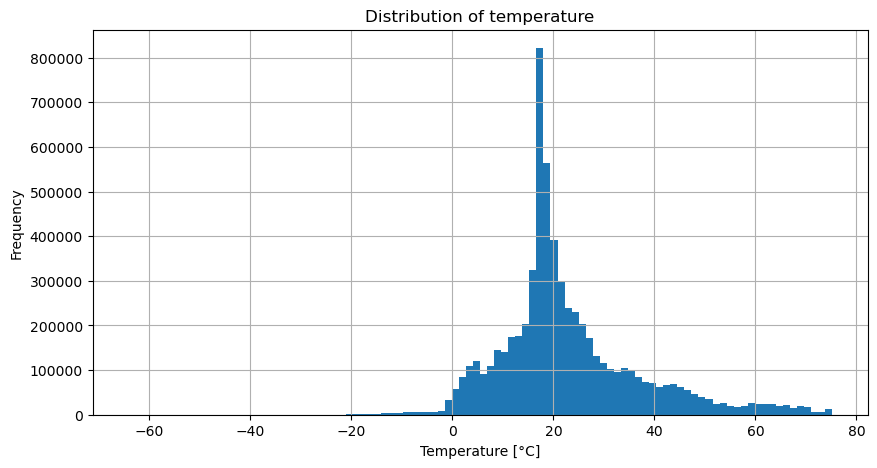

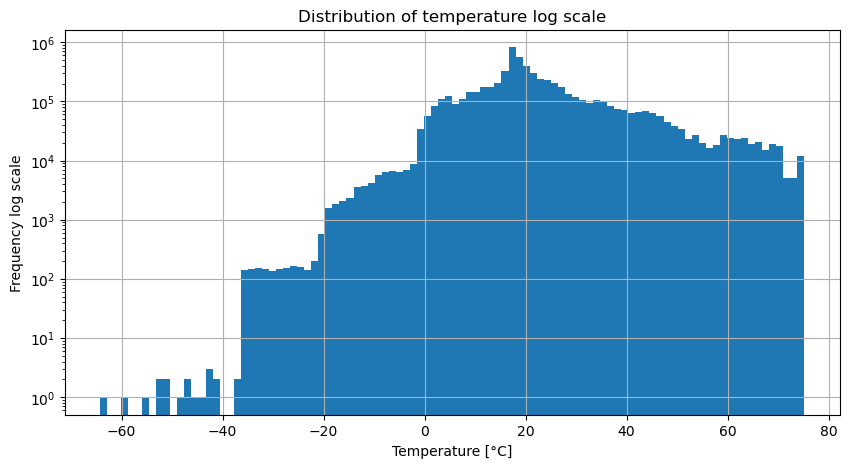

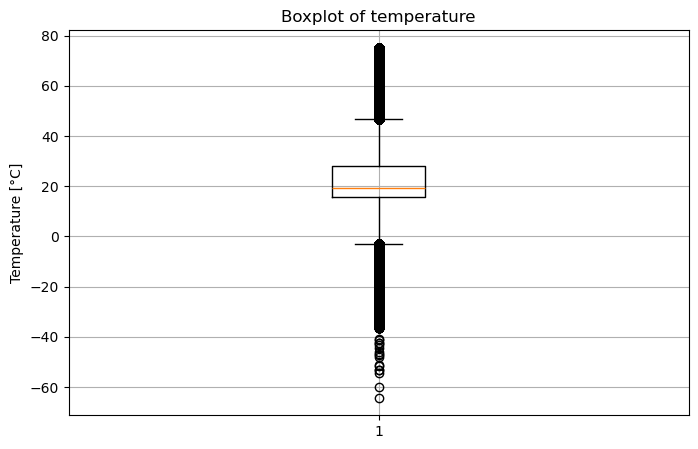

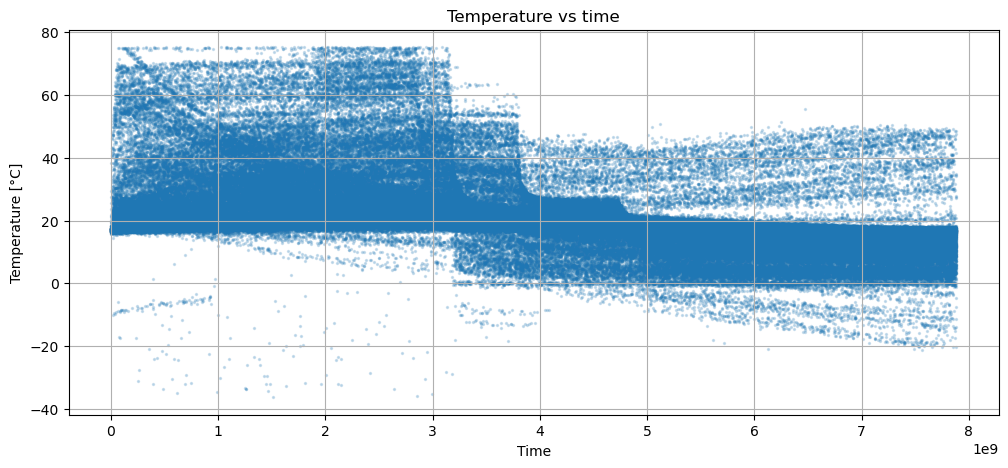

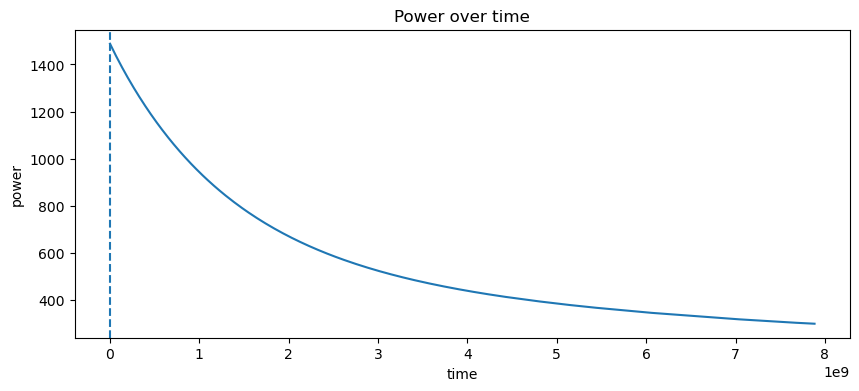

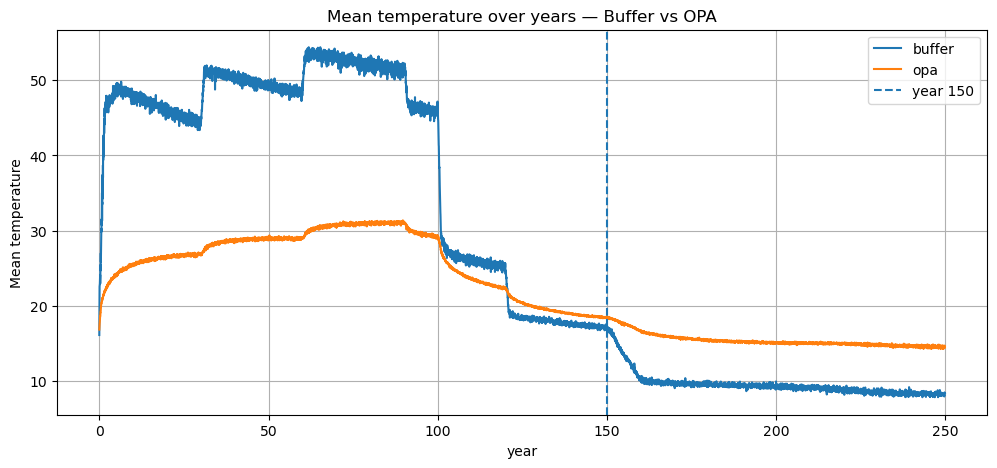

In [13]:
train_full["temperature"].describe(percentiles=[
    0.001, 0.005, 0.01, 0.05,
    0.25, 0.5, 0.75,
    0.95, 0.99, 0.995, 0.999
])
print("Temperature min:", train_full["temperature"].min())
print("Temperature max:", train_full["temperature"].max())

print("\nPower min:", train_full["power"].min())
print("Power max:", train_full["power"].max())

print("\nTime min:", train_full["time"].min())
print("Time max:", train_full["time"].max())
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency")
plt.title("Distribution of temperature")
plt.grid(True)
plt.show()
plt.figure(figsize=(10, 5))
plt.hist(train_full["temperature"], bins=100)
plt.yscale("log")
plt.xlabel("Temperature [°C]")
plt.ylabel("Frequency log scale")
plt.title("Distribution of temperature log scale")
plt.grid(True)
plt.show()
plt.figure(figsize=(8, 5))
plt.boxplot(train_full["temperature"], vert=True, showfliers=True)
plt.ylabel("Temperature [°C]")
plt.title("Boxplot of temperature")
plt.grid(True)
plt.show()
sample_df = train_full.sample(n=200_000, random_state=42)

plt.figure(figsize=(12, 5))
plt.scatter(
    sample_df["time"],
    sample_df["temperature"],
    s=2,
    alpha=0.2
)
plt.xlabel("Time")
plt.ylabel("Temperature [°C]")
plt.title("Temperature vs time")
plt.grid(True)
plt.show()

# Power_time
power_time = (
    train_full[["time", "power"]]
    .drop_duplicates("time")
    .sort_values("time")
)

plt.figure(figsize=(10, 4))
plt.plot(power_time["time"], power_time["power"])
plt.axvline(150, linestyle="--")
plt.xlabel("time")
plt.ylabel("power")
plt.title("Power over time")
plt.show()


# ============================================================
# Mean temperature over years — BUFFER vs OPA
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

THRESHOLD_X = 1.4
SECONDS_PER_YEAR = 365.25 * 24 * 3600

df = train_full.copy()

df["year"] = df["time"] / SECONDS_PER_YEAR

df["zone"] = np.where(
    df["coor_x"] < THRESHOLD_X,
    "buffer",
    "opa"
)

temp_mean_by_year = (
    df
    .groupby(["year", "zone"], as_index=False)["temperature"]
    .mean()
    .rename(columns={"temperature": "mean_temperature"})
)

plt.figure(figsize=(12, 5))

for zone_name in ["buffer", "opa"]:
    df_zone = temp_mean_by_year[temp_mean_by_year["zone"] == zone_name]
    plt.plot(
        df_zone["year"],
        df_zone["mean_temperature"],
        label=zone_name
    )

plt.axvline(150, linestyle="--", label="year 150")

plt.xlabel("year")
plt.ylabel("Mean temperature")
plt.title("Mean temperature over years — Buffer vs OPA")
plt.legend()
plt.grid(True)
plt.show()

## Note: this cell can be skipped

In [14]:
train_buffer = train_full[train_full["coor_x"] < 1.4].copy()
train_opa = train_full[train_full["coor_x"] > 1.4].copy()
print(train_buffer.shape)
print(train_opa.shape)



(1159166, 7)
(4958844, 7)


## Cumulative energy feature

In [15]:
# Creo una tabella temporale unica con time e power
power_time = (
    train_full[["time", "power"]]
    .drop_duplicates()
    .sort_values("time")
    .copy()
)

# Differenza temporale tra istanti successivi
power_time["dt"] = power_time["time"].diff().fillna(0)

# Energia cumulata approssimata
power_time["cum_energy"] = (power_time["power"] * power_time["dt"]).cumsum()

# Merge nel dataset principale
train_full = train_full.merge(
    power_time[["time", "cum_energy"]],
    on="time",
    how="left"
)

## Keep raw time


In [16]:
train_full = train_full.dropna(subset=["temperature"])


## Power/d2 & diffusion

In [17]:
eps = 1e-8

# Distanza quadratica dalla sorgente/origine
train_full["dist2"] = train_full["coor_x"]**2 + train_full["coor_y"]**2

# Potenza pesata per distanza quadratica
train_full["power_over_dist2"] = train_full["power"] / (train_full["dist2"] + eps)

# Feature tipo diffusione: distanza^2 / tempo
train_full["diffusion"] = train_full["dist2"] / (train_full["time"] + eps)

## Aggiungi feature temporali di regime

In [18]:
# ============================================================
# Time/regime features
# ============================================================

SECONDS_PER_YEAR = 365.25 * 24 * 3600

def add_time_regime_features(df):
    df = df.copy()

    df["year"] = df["time"] / SECONDS_PER_YEAR

    # Non-linear time features
    df["year2"] = df["year"] ** 2
    df["sqrt_year"] = np.sqrt(df["year"] + 1e-8)
    df["log_year"] = np.log1p(df["year"])

    # Regime indicators based on visible jumps
    breakpoints = [30, 60, 90, 100, 120, 150, 160]

    for b in breakpoints:
        df[f"after_{b}"] = (df["year"] >= b).astype(float)
        df[f"dist_from_{b}"] = np.abs(df["year"] - b)
        df[f"smooth_after_{b}"] = 1 / (1 + np.exp(-(df["year"] - b) / 3))

    return df

train_full = add_time_regime_features(train_full)

## Feature spazio-tempo

In [19]:
def add_space_time_features(df):
    df = df.copy()

    df["year_x"] = df["year"] * df["coor_x"]
    df["year_y"] = df["year"] * df["coor_y"]
    df["year_dist2"] = df["year"] * df["dist2"]

    df["power_year"] = df["power"] * df["year"]
    df["cum_energy_year"] = df["cum_energy"] * df["year"]

    df["power_x"] = df["power"] * df["coor_x"]
    df["power_y"] = df["power"] * df["coor_y"]
    df["power_dist2"] = df["power"] * df["dist2"]

    return df

In [20]:
train_full = add_space_time_features(train_full)

## Train/validation split by sensor (separate per zone) & normalization

In [21]:
from sklearn.preprocessing import StandardScaler
import numpy as np

base_feature_cols = [
    "time", "power", "coor_x", "coor_y",
    "cum_energy", "dist2", "power_over_dist2", "diffusion",

    "year", "year2", "sqrt_year", "log_year",

    "after_30", "after_60", "after_90", "after_100",
    "after_120", "after_150", "after_160",

    "dist_from_30", "dist_from_60", "dist_from_90", "dist_from_100",
    "dist_from_120", "dist_from_150", "dist_from_160",

    "smooth_after_30", "smooth_after_60", "smooth_after_90",
    "smooth_after_100", "smooth_after_120",
    "smooth_after_150", "smooth_after_160"
]

space_time_features = [
    "year_x", "year_y", "year_dist2",
    "power_year", "cum_energy_year",
    "power_x", "power_y", "power_dist2"
]

feature_cols_buf = base_feature_cols + space_time_features
feature_cols_opa = base_feature_cols

target_col = "temperature"

# ============================================================
# Zone split: buffer (coor_x < 1.4) vs OPA (coor_x > 1.4)
# ============================================================
THRESHOLD_X = 1.4

train_buffer_all = train_full[train_full["coor_x"] < THRESHOLD_X].copy()
train_opa_all    = train_full[train_full["coor_x"] >= THRESHOLD_X].copy()

print(f"Buffer zone rows : {len(train_buffer_all)}")
print(f"OPA zone rows    : {len(train_opa_all)}")

rng = np.random.default_rng(42)

def sensor_split(df, val_frac=0.2, label=""):
    sensors = df["sensor"].unique()
    val_s   = rng.choice(sensors, size=int(val_frac * len(sensors)), replace=False)
    train_s = np.setdiff1d(sensors, val_s)
    tr  = df[df["sensor"].isin(train_s)].copy()
    val = df[df["sensor"].isin(val_s)].copy()
    assert set(tr["sensor"]).isdisjoint(set(val["sensor"]))
    print(f"  [{label}] train sensors: {len(train_s)} | val sensors: {len(val_s)} | "
          f"train rows: {len(tr)} | val rows: {len(val)}")
    return tr, val

print("\nBuffer split:")
train_df_buf, val_df_buf = sensor_split(train_buffer_all, label="buffer")

print("\nOPA split:")
train_df_opa, val_df_opa = sensor_split(train_opa_all, label="OPA")

# ---- Numpy arrays per zone ----
def to_xy(df, cols):
    X = df[cols].to_numpy(dtype=np.float32, copy=False)
    y = df[[target_col]].to_numpy(dtype=np.float32, copy=False)
    return X, y

X_train_buf, y_train_buf = to_xy(train_df_buf, feature_cols_buf)
X_val_buf,   y_val_buf   = to_xy(val_df_buf, feature_cols_buf)

X_train_opa, y_train_opa = to_xy(train_df_opa, feature_cols_opa)
X_val_opa,   y_val_opa   = to_xy(val_df_opa, feature_cols_opa)

# ---- Separate scalers (fit on train only) ----
scaler_X_buf = StandardScaler()
scaler_y_buf = StandardScaler()

X_train_norm_buf = scaler_X_buf.fit_transform(X_train_buf)
X_val_norm_buf   = scaler_X_buf.transform(X_val_buf)
y_train_norm_buf = scaler_y_buf.fit_transform(y_train_buf)
y_val_norm_buf   = scaler_y_buf.transform(y_val_buf)

scaler_X_opa = StandardScaler()
scaler_y_opa = StandardScaler()

X_train_norm_opa = scaler_X_opa.fit_transform(X_train_opa)
X_val_norm_opa   = scaler_X_opa.transform(X_val_opa)
y_train_norm_opa = scaler_y_opa.fit_transform(y_train_opa)
y_val_norm_opa   = scaler_y_opa.transform(y_val_opa)

# Sanity checks
for name, Xn, yn in [
    ("buf train", X_train_norm_buf, y_train_norm_buf),
    ("buf val",   X_val_norm_buf,   y_val_norm_buf),
    ("opa train", X_train_norm_opa, y_train_norm_opa),
    ("opa val",   X_val_norm_opa,   y_val_norm_opa),
]:
    print(f"{name} — NaN X:{np.isnan(Xn).sum()} Inf X:{np.isinf(Xn).sum()} "
          f"| NaN y:{np.isnan(yn).sum()} Inf y:{np.isinf(yn).sum()}")


Buffer zone rows : 3007758
OPA zone rows    : 13606225

Buffer split:
  [buffer] train sensors: 36 | val sensors: 9 | train rows: 2407630 | val rows: 600128

OPA split:
  [OPA] train sensors: 156 | val sensors: 39 | train rows: 10881926 | val rows: 2724299
buf train — NaN X:0 Inf X:0 | NaN y:0 Inf y:0
buf val — NaN X:0 Inf X:0 | NaN y:0 Inf y:0
opa train — NaN X:0 Inf X:0 | NaN y:0 Inf y:0
opa val — NaN X:0 Inf X:0 | NaN y:0 Inf y:0


In [22]:
print(train_full["temperature"].isna().sum())
print(train_full.isna().sum())


0
sensor              0
time                0
power               0
temperature         0
coor_x              0
coor_y              0
coor_z              0
cum_energy          0
dist2               0
power_over_dist2    0
diffusion           0
year                0
year2               0
sqrt_year           0
log_year            0
after_30            0
dist_from_30        0
smooth_after_30     0
after_60            0
dist_from_60        0
smooth_after_60     0
after_90            0
dist_from_90        0
smooth_after_90     0
after_100           0
dist_from_100       0
smooth_after_100    0
after_120           0
dist_from_120       0
smooth_after_120    0
after_150           0
dist_from_150       0
smooth_after_150    0
after_160           0
dist_from_160       0
smooth_after_160    0
year_x              0
year_y              0
year_dist2          0
power_year          0
cum_energy_year     0
power_x             0
power_y             0
power_dist2         0
dtype: int64


In [23]:
print(train_full[train_full["temperature"].isna()].head())


Empty DataFrame
Columns: [sensor, time, power, temperature, coor_x, coor_y, coor_z, cum_energy, dist2, power_over_dist2, diffusion, year, year2, sqrt_year, log_year, after_30, dist_from_30, smooth_after_30, after_60, dist_from_60, smooth_after_60, after_90, dist_from_90, smooth_after_90, after_100, dist_from_100, smooth_after_100, after_120, dist_from_120, smooth_after_120, after_150, dist_from_150, smooth_after_150, after_160, dist_from_160, smooth_after_160, year_x, year_y, year_dist2, power_year, cum_energy_year, power_x, power_y, power_dist2]
Index: []

[0 rows x 44 columns]


## Visualizzazione della distribuzione spaziale dei sensori (per zona)

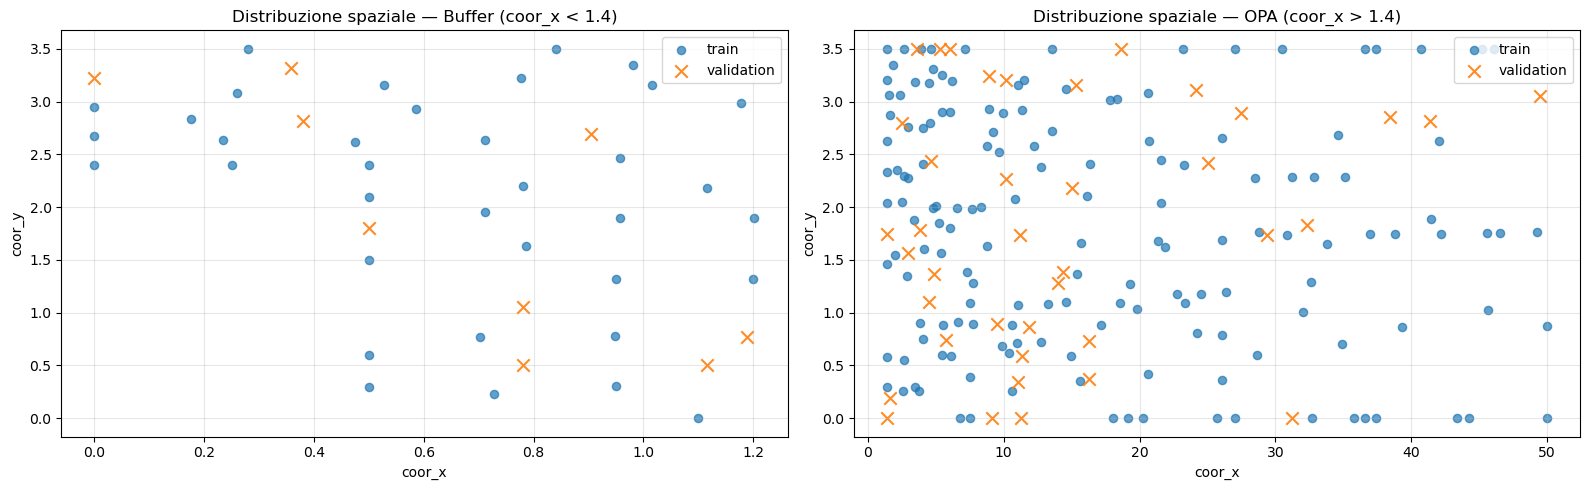

In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tr, val, title in [
    (axes[0], train_df_buf, val_df_buf, "Buffer (coor_x < 1.4)"),
    (axes[1], train_df_opa, val_df_opa, "OPA (coor_x > 1.4)"),
]:
    tr_pos  = tr.groupby("sensor")[["coor_x","coor_y"]].mean().reset_index()
    val_pos = val.groupby("sensor")[["coor_x","coor_y"]].mean().reset_index()

    ax.scatter(tr_pos["coor_x"],  tr_pos["coor_y"],  s=35, label="train",      alpha=0.7)
    ax.scatter(val_pos["coor_x"], val_pos["coor_y"], s=80, label="validation",  alpha=0.9, marker="x")

    ax.set_xlabel("coor_x")
    ax.set_ylabel("coor_y")
    ax.set_title(f"Distribuzione spaziale — {title}")
    ax.legend(loc="upper right")
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()


## Neural Network architecture

In [25]:
class TemperatureNN(nn.Module):
    """
    Deep neural network for temperature regression.
    Architecture: input -> 128 -> 128 -> 64 -> 1
    BatchNorm + Dropout for regularization.
    """
    def __init__(self, input_dim, hidden=128, dropout=0.1):
        super().__init__()
        self.network = nn.Sequential(
            nn.Linear(input_dim, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden),
            nn.BatchNorm1d(hidden),
            nn.ReLU(),
            nn.Dropout(dropout),

            nn.Linear(hidden, hidden // 2),
            nn.BatchNorm1d(hidden // 2),
            nn.ReLU(),
            nn.Dropout(dropout / 2),

            nn.Linear(hidden // 2, 1)
        )

    def forward(self, x):
        return self.network(x)


## Weight initialization (Kaiming)

In [26]:
def initialize_weights(model):
    for layer in model.modules():
        if isinstance(layer, nn.Linear):
            nn.init.kaiming_normal_(layer.weight, nonlinearity="relu")

            if layer.bias is not None:
                nn.init.zeros_(layer.bias)

## Create tensors and move to GPU (buffer & OPA)

In [27]:
# Buffer tensors
X_train_tensor_buf = torch.tensor(X_train_norm_buf, dtype=torch.float32, device=device)
y_train_tensor_buf = torch.tensor(y_train_norm_buf, dtype=torch.float32, device=device)
X_val_tensor_buf   = torch.tensor(X_val_norm_buf,   dtype=torch.float32, device=device)
y_val_tensor_buf   = torch.tensor(y_val_norm_buf,   dtype=torch.float32, device=device)

# OPA tensors
X_train_tensor_opa = torch.tensor(X_train_norm_opa, dtype=torch.float32, device=device)
y_train_tensor_opa = torch.tensor(y_train_norm_opa, dtype=torch.float32, device=device)
X_val_tensor_opa   = torch.tensor(X_val_norm_opa,   dtype=torch.float32, device=device)
y_val_tensor_opa   = torch.tensor(y_val_norm_opa,   dtype=torch.float32, device=device)

print("Buffer  — train:", X_train_tensor_buf.shape, "| val:", X_val_tensor_buf.shape)
print("OPA     — train:", X_train_tensor_opa.shape, "| val:", X_val_tensor_opa.shape)


Buffer  — train: torch.Size([2407630, 41]) | val: torch.Size([600128, 41])
OPA     — train: torch.Size([10881926, 33]) | val: torch.Size([2724299, 33])


## Model instantiation (one per zone)

In [28]:
model_buf = TemperatureNN(
    input_dim=len(feature_cols_buf),
    hidden=128,
    dropout=0.1
).to(device)

model_opa = TemperatureNN(
    input_dim=len(feature_cols_opa),
    hidden=128,
    dropout=0.1
).to(device)

initialize_weights(model_buf)
initialize_weights(model_opa)

for name, m in [("Buffer", model_buf), ("OPA", model_opa)]:
    total = sum(p.numel() for p in m.parameters())
    print(f"{name} model — Parameters: {total:,} | Device: {device}")


Buffer model — Parameters: 30,849 | Device: cuda
OPA model — Parameters: 29,825 | Device: cuda


## Loss, optimizer & regularization

In [29]:
# Loss function and optimizer are defined inside train_model().
# This cell is kept for reference only — no need to run it.
#
# loss_fn = nn.HuberLoss(delta=1.0)
# optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)


## Training loop (buffer & OPA separately)

In [30]:
def train_model(model, X_train_t, y_train_t, X_val_t, y_val_t,
                zone_name="model",
                batch_size=65536, num_epochs=100, patience=50, min_delta=1e-5):
    """
    Train a single model with early stopping.
    Returns the trained model (best weights reloaded) and loss history.
    """
    best_path = f"best_{zone_name}_model.pt"

    optimizer = torch.optim.AdamW(model.parameters(), lr=1e-4, weight_decay=1e-3)
    loss_fn   = nn.HuberLoss(delta=1.0)

    best_val_loss = float("inf")
    counter = 0
    train_losses, val_losses = [], []

    for epoch in range(num_epochs):
        model.train()
        perm = torch.randperm(X_train_t.shape[0], device=device)
        train_loss_sum = 0.0

        for i in range(0, X_train_t.shape[0], batch_size):
            idx = perm[i:i+batch_size]
            Xb, yb = X_train_t[idx], y_train_t[idx]

            optimizer.zero_grad(set_to_none=True)
            pred = model(Xb)
            loss = loss_fn(pred, yb)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            train_loss_sum += loss.item() * Xb.shape[0]

        train_loss = train_loss_sum / X_train_t.shape[0]

        model.eval()
        with torch.no_grad():
            val_loss = loss_fn(model(X_val_t), y_val_t).item()

        train_losses.append(train_loss)
        val_losses.append(val_loss)

        print(f"[{zone_name}] Epoch {epoch:03d} | train {train_loss:.6f} | val {val_loss:.6f}")

        if val_loss < best_val_loss - min_delta:
            best_val_loss = val_loss
            counter = 0
            torch.save(model.state_dict(), best_path)
        else:
            counter += 1
            if counter >= patience:
                print(f"[{zone_name}] Early stopping at epoch {epoch} — best val: {best_val_loss:.6f}")
                break

    model.load_state_dict(torch.load(best_path))
    print(f"[{zone_name}] Training done. Best val loss: {best_val_loss:.6f}")
    return model, train_losses, val_losses


print("=" * 60)
print("Training BUFFER model")
print("=" * 60)
model_buf, tl_buf, vl_buf = train_model(
    model_buf,
    X_train_tensor_buf, y_train_tensor_buf,
    X_val_tensor_buf,   y_val_tensor_buf,
    zone_name="buffer"
)

print()
print("=" * 60)
print("Training OPA model")
print("=" * 60)
model_opa, tl_opa, vl_opa = train_model(
    model_opa,
    X_train_tensor_opa, y_train_tensor_opa,
    X_val_tensor_opa,   y_val_tensor_opa,
    zone_name="opa"
)


Training BUFFER model
[buffer] Epoch 000 | train 0.373016 | val 0.120790
[buffer] Epoch 001 | train 0.202805 | val 0.092472
[buffer] Epoch 002 | train 0.135921 | val 0.094034
[buffer] Epoch 003 | train 0.108565 | val 0.091605
[buffer] Epoch 004 | train 0.095103 | val 0.086227
[buffer] Epoch 005 | train 0.084821 | val 0.079134
[buffer] Epoch 006 | train 0.077243 | val 0.074048
[buffer] Epoch 007 | train 0.071064 | val 0.070443
[buffer] Epoch 008 | train 0.066434 | val 0.066967
[buffer] Epoch 009 | train 0.063330 | val 0.066279
[buffer] Epoch 010 | train 0.060137 | val 0.065104
[buffer] Epoch 011 | train 0.057981 | val 0.063654
[buffer] Epoch 012 | train 0.055355 | val 0.064427
[buffer] Epoch 013 | train 0.054157 | val 0.063640
[buffer] Epoch 014 | train 0.051700 | val 0.062880
[buffer] Epoch 015 | train 0.050076 | val 0.062761
[buffer] Epoch 016 | train 0.048858 | val 0.062154
[buffer] Epoch 017 | train 0.047062 | val 0.062016
[buffer] Epoch 018 | train 0.045788 | val 0.061899
[buffer] 

## Evaluate on validation set (buffer & OPA)

In [31]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

def evaluate_model(model, X_val_t, y_val_t, scaler_y, zone_name="model"):
    model.eval()
    with torch.no_grad():
        y_pred_norm = model(X_val_t).cpu().numpy()
    y_true_norm = y_val_t.cpu().numpy()

    y_pred = scaler_y.inverse_transform(y_pred_norm)
    y_true = scaler_y.inverse_transform(y_true_norm)

    mae  = mean_absolute_error(y_true, y_pred)
    rmse = np.sqrt(mean_squared_error(y_true, y_pred))
    r2   = r2_score(y_true, y_pred)

    print(f"[{zone_name}] MAE: {mae:.4f} °C | RMSE: {rmse:.4f} °C | R²: {r2:.4f}")
    return y_true, y_pred

print("Buffer validation:")
y_val_true_buf, y_val_pred_buf = evaluate_model(
    model_buf, X_val_tensor_buf, y_val_tensor_buf, scaler_y_buf, "buffer")

print("\nOPA validation:")
y_val_true_opa, y_val_pred_opa = evaluate_model(
    model_opa, X_val_tensor_opa, y_val_tensor_opa, scaler_y_opa, "OPA")


Buffer validation:
[buffer] MAE: 3.6471 °C | RMSE: 7.5871 °C | R²: 0.8936

OPA validation:
[OPA] MAE: 2.4992 °C | RMSE: 5.2343 °C | R²: 0.7654


## Compare with baseline (per zone)

In [32]:
for zone, y_train_raw, y_val_true, y_val_pred in [
    ("buffer", y_train_buf, y_val_true_buf, y_val_pred_buf),
    ("OPA",    y_train_opa, y_val_true_opa, y_val_pred_opa),
]:
    baseline = np.full_like(y_val_true, y_train_raw.mean())
    b_mae    = mean_absolute_error(y_val_true, baseline)
    b_rmse   = np.sqrt(mean_squared_error(y_val_true, baseline))
    print(f"[{zone}] Baseline MAE: {b_mae:.4f} °C | RMSE: {b_rmse:.4f} °C")


[buffer] Baseline MAE: 20.2217 °C | RMSE: 23.3770 °C
[OPA] Baseline MAE: 8.0065 °C | RMSE: 10.8436 °C


## Error analysis by sensor (per zone)

In [33]:
def sensor_error_analysis(val_df, y_true, y_pred, label):
    res = val_df.copy()
    res["y_true"]    = y_true.ravel()
    res["y_pred"]    = y_pred.ravel()
    res["abs_error"] = np.abs(res["y_true"] - res["y_pred"])
    res["sq_error"]  = (res["y_true"] - res["y_pred"]) ** 2

    metrics = (
        res.groupby("sensor")
        .agg(
            mae      =("abs_error", "mean"),
            rmse     =("sq_error",  lambda x: np.sqrt(np.mean(x))),
            coor_x   =("coor_x",    "first"),
            coor_y   =("coor_y",    "first"),
            true_mean=("y_true",    "mean"),
            pred_mean=("y_pred",    "mean"),
        )
        .sort_values("mae", ascending=False)
    )
    print(f"\n[{label}] Top 20 sensors by MAE:")
    print(metrics.head(20))
    return res, metrics

val_results_buf, sensor_metrics_buf = sensor_error_analysis(
    val_df_buf, y_val_true_buf, y_val_pred_buf, "buffer")

val_results_opa, sensor_metrics_opa = sensor_error_analysis(
    val_df_opa, y_val_true_opa, y_val_pred_opa, "OPA")



[buffer] Top 20 sensors by MAE:
              mae       rmse    coor_x    coor_y  true_mean  pred_mean
sensor                                                                
N918    21.624743  22.764496  0.358713  3.314945  15.587447  37.211773
N923     4.603073   5.392082  1.189514  0.766669  24.209570  28.680088
N925     2.007740   2.492165  0.904999  2.692162  30.132950  31.407978
N908     1.628249   3.335421  1.115825  0.500653  30.271412  29.212976
N904     1.604721   3.163382  0.780101  1.049624  31.653439  32.475807
N909     1.508280   3.244735  0.780347  0.500008  31.704584  30.864454
N186     1.235224   3.038046  0.000000  3.225000  30.397860  29.966051
N201     1.188591   3.186108  0.500000  1.800000  25.115898  24.732924
N893     1.042032   3.041213  0.380644  2.812957  31.077028  30.687321

[OPA] Top 20 sensors by MAE:
              mae       rmse     coor_x    coor_y  true_mean  pred_mean
sensor                                                                 
N821    18.8

## Plot predictions vs true values (per zone)

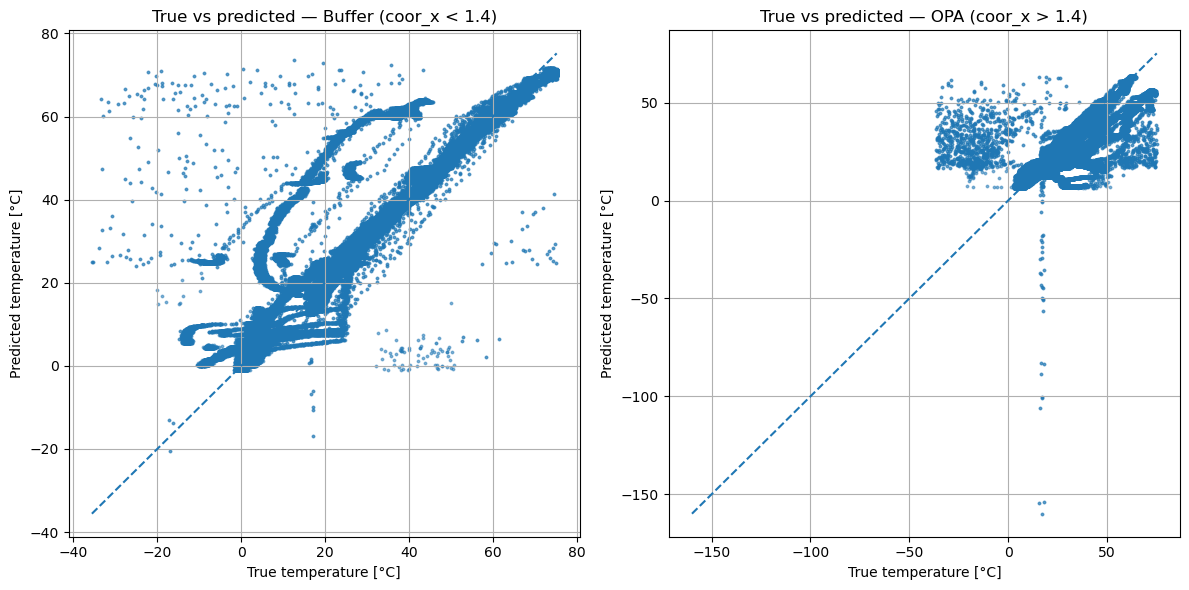

In [34]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 6))

for ax, y_true, y_pred, title in [
    (axes[0], y_val_true_buf, y_val_pred_buf, "Buffer (coor_x < 1.4)"),
    (axes[1], y_val_true_opa, y_val_pred_opa, "OPA (coor_x > 1.4)"),
]:
    ax.scatter(y_true, y_pred, s=3, alpha=0.3)
    lo = min(y_true.min(), y_pred.min())
    hi = max(y_true.max(), y_pred.max())
    ax.plot([lo, hi], [lo, hi], linestyle="--")
    ax.set_xlabel("True temperature [°C]")
    ax.set_ylabel("Predicted temperature [°C]")
    ax.set_title(f"True vs predicted — {title}")
    ax.grid(True)

plt.tight_layout()
plt.show()


## Error analysis over time (per zone)

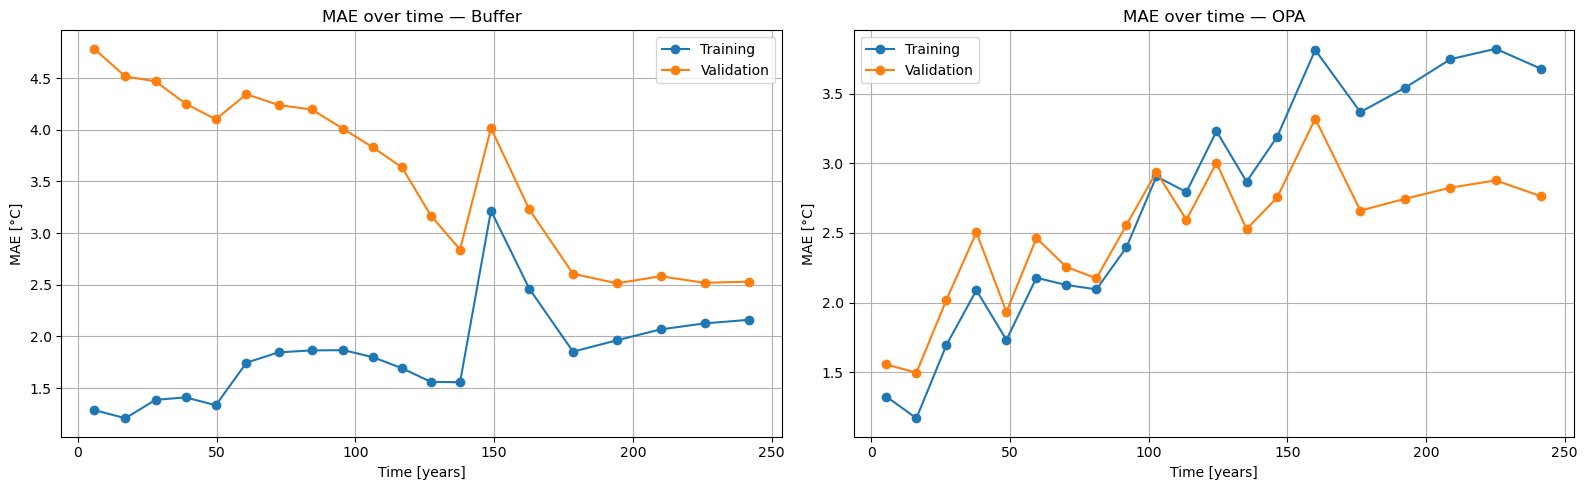

In [35]:
# Error over time for training sets (re-predict)
def predict_train(model, X_train_norm, scaler_y, device):
    model.eval()
    t = torch.tensor(X_train_norm, dtype=torch.float32, device=device)
    with torch.no_grad():
        pred_norm = model(t).cpu().numpy()
    return scaler_y.inverse_transform(pred_norm)

y_train_pred_buf = predict_train(model_buf, X_train_norm_buf, scaler_y_buf, device)
y_train_pred_opa = predict_train(model_opa, X_train_norm_opa, scaler_y_opa, device)

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

for ax, tr_df, val_res, y_tr_true, y_tr_pred, y_vl_true, y_vl_pred, title in [
    (axes[0], train_df_buf, val_results_buf,
     y_train_buf, y_train_pred_buf,
     y_val_true_buf, y_val_pred_buf, "Buffer"),
    (axes[1], train_df_opa, val_results_opa,
     y_train_opa, y_train_pred_opa,
     y_val_true_opa, y_val_pred_opa, "OPA"),
]:
    tr_res = tr_df.copy()
    tr_res["temperature_true"] = y_tr_true.ravel()
    tr_res["temperature_pred"] = y_tr_pred.ravel()
    tr_res["abs_error"] = np.abs(tr_res["temperature_true"] - tr_res["temperature_pred"])
    tr_res["time_years"] = tr_res["time"] / (365.25 * 24 * 3600)
    val_res["time_years"] = val_res["time"] / (365.25 * 24 * 3600)

    all_t = pd.concat([tr_res["time_years"], val_res["time_years"]])
    bins  = pd.qcut(all_t, q=20, duplicates="drop").cat.categories

    def mae_over_time(df, col_err, bins):
        return (
            df.groupby(pd.cut(df["time_years"], bins=bins, include_lowest=True), observed=False)
            .agg(mae=(col_err, "mean"))
            .reset_index()
            .assign(t_mid=lambda x: x["time_years"].apply(lambda iv: iv.mid))
        )

    tr_t  = mae_over_time(tr_res,  "abs_error", bins)
    vl_t  = mae_over_time(val_res, "abs_error", bins)

    ax.plot(tr_t["t_mid"], tr_t["mae"], marker="o", label="Training")
    ax.plot(vl_t["t_mid"], vl_t["mae"], marker="o", label="Validation")
    ax.set_xlabel("Time [years]")
    ax.set_ylabel("MAE [°C]")
    ax.set_title(f"MAE over time — {title}")
    ax.legend()
    ax.grid(True)

plt.tight_layout()
plt.show()


## Final predictions & submission file

In [36]:
# ============================================================
# Final predictions & submission — two models (buffer / OPA)
# ============================================================

THRESHOLD_X = 1.4

# Reload test & sensors
test       = pd.read_parquet("test.parquet")
sensors_df = pd.read_parquet("sensors.parquet")
sensors_df = sensors_df.drop_duplicates(subset="sensor", keep="first")

test_full = test.merge(sensors_df, on="sensor", how="left")

# Cumulative energy
power_time = (
    test_full[["time", "power"]]
    .drop_duplicates(subset=["time"])
    .sort_values("time")
    .copy()
)
power_time["dt"]         = power_time["time"].diff().fillna(0)
power_time["cum_energy"] = (power_time["power"] * power_time["dt"]).cumsum()

test_full = test_full.merge(
    power_time[["time", "cum_energy"]].drop_duplicates(subset=["time"]),
    on="time", how="left"
)

# Engineered features
eps = 1e-8
test_full["dist2"]           = test_full["coor_x"]**2 + test_full["coor_y"]**2
test_full["power_over_dist2"] = test_full["power"] / (test_full["dist2"] + eps)
test_full["diffusion"]        = test_full["dist2"] / (test_full["time"] + eps)

# Time/regime features
test_full = add_time_regime_features(test_full)

# Space-time interaction features
test_full = add_space_time_features(test_full)

print(f"test_full shape: {test_full.shape}")

# ---- Split test by zone ----
test_buf_mask = test_full["coor_x"] < THRESHOLD_X
test_opa_mask = test_full["coor_x"] >= THRESHOLD_X

test_buf = test_full[test_buf_mask].copy()
test_opa = test_full[test_opa_mask].copy()

print(f"  Buffer test rows: {len(test_buf)}  | OPA test rows: {len(test_opa)}")
assert len(test_buf) + len(test_opa) == len(test_full), "Row count mismatch after split!"

# ---- Predict buffer ----
X_test_buf = test_buf[feature_cols_buf].to_numpy(dtype=np.float32)
X_test_norm_buf = scaler_X_buf.transform(X_test_buf)
X_test_t_buf    = torch.tensor(X_test_norm_buf, dtype=torch.float32, device=device)

model_buf.eval()
with torch.no_grad():
    y_test_pred_norm_buf = model_buf(X_test_t_buf).cpu().numpy()
y_test_pred_buf = scaler_y_buf.inverse_transform(y_test_pred_norm_buf).ravel()

# ---- Predict OPA ----
X_test_opa = test_opa[feature_cols_opa].to_numpy(dtype=np.float32)
X_test_norm_opa = scaler_X_opa.transform(X_test_opa)
X_test_t_opa    = torch.tensor(X_test_norm_opa, dtype=torch.float32, device=device)

model_opa.eval()
with torch.no_grad():
    y_test_pred_norm_opa = model_opa(X_test_t_opa).cpu().numpy()
y_test_pred_opa = scaler_y_opa.inverse_transform(y_test_pred_norm_opa).ravel()

# ---- Recombine in original order ----
# Use the integer index from test_full to reconstruct original ordering
test_buf["temperature_pred"] = y_test_pred_buf
test_opa["temperature_pred"] = y_test_pred_opa

predictions = pd.concat([test_buf, test_opa]).sort_index()

assert len(predictions) == len(test_full), "Row count mismatch after recombination!"
# Make sure index alignment is correct
assert (predictions.index == test_full.index).all(), "Index mismatch after recombination!"

y_test_pred = predictions["temperature_pred"].values

# ---- Submission ----
submission = pd.DataFrame({
    "Id":          np.arange(len(test), dtype=int),
    "temperature": y_test_pred.astype(float)
})

assert list(submission.columns) == ["Id", "temperature"]
assert len(submission) == len(test)
assert np.isfinite(submission["temperature"]).all()
assert submission.isna().sum().sum() == 0

submission.to_csv("submission.csv", index=False)
print(f"submission.csv saved — {len(submission)} rows")
display(submission.head(10))


test_full shape: (2190480, 43)
  Buffer test rows: 410715  | OPA test rows: 1779765
submission.csv saved — 2190480 rows


,Id,temperature
0,0,17.117268
1,1,17.149948
2,2,17.181147
3,3,17.211227
4,4,17.240131
5,5,17.265844
6,6,17.282417
7,7,17.298182
8,8,17.313704
9,9,17.322615
